In [122]:

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import root_mean_squared_error
from sklearn.feature_selection import VarianceThreshold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

from xgboost import XGBRegressor as xgb


import matplotlib.pyplot as plt


In [123]:
%run ./ml_model_init.ipynb

## Data


In [124]:

xa_data= data[(data['minutes_5'] >= 300) & (data['position'] != 'GK')][['position', 'minutes_3', 'minutes_5', 'team_h_difficulty', 'team_a_difficulty', 'ict_index_3',  'ict_index_5',
                                                                        'influence_3', 'influence_5', 'creativity_3', 'creativity_5', 'threat_3', 'threat_5', 'was_home',
                                                                        'expected_assists', 'xA_3', 'xA_5',  'expected_goals_conceded_3', 'expected_goals_conceded_5',
                                                                        'expected_assists_3', 'expected_assists_5', 'whh', 'whd', 'wha']]



xa_data_tar = data_tar[(data_tar['minutes_5'] >= 300) & (data_tar['position'] != 'GK')][['position', 'minutes_3', 'minutes_5', 'team_h_difficulty', 'team_a_difficulty', 'ict_index_3',  'ict_index_5',
                                                                        'influence_3', 'influence_5', 'creativity_3', 'creativity_5', 'threat_3', 'threat_5', 'was_home',
                                                                        'expected_assists', 'xA_3', 'xA_5',  'expected_goals_conceded_3', 'expected_goals_conceded_5',
                                                                        'expected_assists_3', 'expected_assists_5', 'whh', 'whd', 'wha']]

In [125]:
xa_data = xa_data.dropna()
xa = xa_data[['expected_assists']]
feats = xa_data.drop('expected_assists', axis=1)
# print(feats.shape, xa.shape)
feats.drop(['position'], axis=1)

# position = feats['position']
OHE = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded = OHE.fit_transform(feats[['position', 'was_home']])
# print(OHE.categories_)

one_hot_df = pd.DataFrame(encoded,  columns=OHE.get_feature_names_out(['position', 'was_home']))

feats_ = feats.drop(['position', 'was_home'], axis=1).reset_index().drop('index', axis=1)

feats_sklearn_encoded = pd.concat([feats_, one_hot_df], axis=1)
# feats_sklearn_encoded

scaler = StandardScaler()

scaled = scaler.fit_transform(feats_sklearn_encoded)
feats_sklearn_enc_scaled = pd.DataFrame(scaled, columns=[feats_sklearn_encoded.columns])



In [126]:
# feats = feats[feats['position'].notnull()]
feats_train, feats_test, xa_train, xa_test = train_test_split(feats_sklearn_enc_scaled, xa , test_size=0.2, random_state=42)


In [127]:
print(feats_train.shape, xa_train.shape)

(8824, 26) (8824, 1)


## Baseline Model


#### Linear Model


In [128]:

lin_reg = Linear_regression(feats_train, feats_test, xa_train, xa_test)

# Store the model evaluation details in a DataFrame
evaluation_stats = pd.DataFrame({"lin_reg": [lin_reg['train_MAE'], lin_reg['test_MAE'], lin_reg['train_RMSE'], lin_reg['test_RMSE'], lin_reg['cv_rmse'], lin_reg['R2_train'], lin_reg['R2_test']]},
                                                        index=(['train_MAE','test_MAE', 'train_RMSE', 'test_RMSE', 'cv_rmse', 'R2_train', 'R2_test']))

evaluation_stats

Training set RMSE: 0.12329154082579676
Test set RMSE: 0.12898989429166877
Training set R2: 0.1538395643256124
Test set R2: 0.1761582756178599


,lin_reg
train_MAE,0.075869
test_MAE,0.078375
train_RMSE,0.123292
test_RMSE,0.128990
cv_rmse,0.123537
R2_train,0.153840
R2_test,0.176158


#### DecisionTree Model


In [129]:
dt_reg = DecisionTreeRegression(feats_train, feats_test, xa_train, xa_test)

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(dt_reg = [dt_reg['train_MAE'], dt_reg['test_MAE'], dt_reg['train_RMSE'], dt_reg['test_RMSE'], dt_reg['cv_rmse'], dt_reg['R2_train'], dt_reg['R2_test']])

evaluation_stats



,lin_reg,dt_reg
train_MAE,0.075869,5.720813e-20
test_MAE,0.078375,1.043064e-01
train_RMSE,0.123292,6.077315e-19
test_RMSE,0.128990,1.820021e-01
cv_rmse,0.123537,1.805701e-01
R2_train,0.153840,1.000000e+00
R2_test,0.176158,-6.401555e-01


#### RandomForest Model


In [130]:
hyperparameters = {"criterion": 'friedman_mse', "max_depth": 8, "max_features": 'sqrt', "n_estimators": 20}
rf_reg = RandomForestRegression(feats_train, feats_test, xa_train.values.ravel(), xa_test.values.ravel(), hyperparameters)

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(rf_reg = [rf_reg['train_MAE'], rf_reg['test_MAE'], rf_reg['train_RMSE'], rf_reg['test_RMSE'], rf_reg['cv_rmse'], rf_reg['R2_train'], rf_reg['R2_test']])

evaluation_stats

,lin_reg,dt_reg,rf_reg
train_MAE,0.075869,5.720813e-20,0.068064
test_MAE,0.078375,1.043064e-01,0.079319
train_RMSE,0.123292,6.077315e-19,0.105516
test_RMSE,0.128990,1.820021e-01,0.129094
cv_rmse,0.123537,1.805701e-01,0.125535
R2_train,0.153840,1.000000e+00,0.380244
R2_test,0.176158,-6.401555e-01,0.174827


#### XgBoost Model


In [131]:
hyperparameters = {'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 150}
xgb_reg = XGBoostRegression(feats_train, feats_test, xa_train, xa_test, hyperparameters)

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(xgb_reg = [xgb_reg['train_MAE'], xgb_reg['test_MAE'], xgb_reg['train_RMSE'], xgb_reg['test_RMSE'], xgb_reg['cv_rmse'], xgb_reg['R2_train'], xgb_reg['R2_test']])
evaluation_stats

,lin_reg,dt_reg,rf_reg,xgb_reg
train_MAE,0.075869,5.720813e-20,0.068064,0.073193
test_MAE,0.078375,1.043064e-01,0.079319,0.078653
train_RMSE,0.123292,6.077315e-19,0.105516,0.116899
test_RMSE,0.128990,1.820021e-01,0.129094,0.128465
cv_rmse,0.123537,1.805701e-01,0.125535,0.123402
R2_train,0.153840,1.000000e+00,0.380244,0.239311
R2_test,0.176158,-6.401555e-01,0.174827,0.182850


### AdaBoost


In [132]:
hyperparameters = {'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 150}
ada_reg = XGBoostRegression(feats_train, feats_test, xa_train, xa_test, hyperparameters)

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(ada_reg = [ada_reg['train_MAE'], ada_reg['test_MAE'], ada_reg['train_RMSE'], ada_reg['test_RMSE'], ada_reg['cv_rmse'], ada_reg['R2_train'], ada_reg['R2_test']])
evaluation_stats

,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg
train_MAE,0.075869,5.720813e-20,0.068064,0.073193,0.073193
test_MAE,0.078375,1.043064e-01,0.079319,0.078653,0.078653
train_RMSE,0.123292,6.077315e-19,0.105516,0.116899,0.116899
test_RMSE,0.128990,1.820021e-01,0.129094,0.128465,0.128465
cv_rmse,0.123537,1.805701e-01,0.125535,0.123402,0.123402
R2_train,0.153840,1.000000e+00,0.380244,0.239311,0.239311
R2_test,0.176158,-6.401555e-01,0.174827,0.182850,0.182850


# Feature engineering


### Data


In [133]:
cols_ = ['expected_assists', 'position', 'team_h_difficulty', 'team_a_difficulty', 'value', 'was_home', 'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_y_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3', 'xP_3', 'selected_3', 'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_y_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5', 'xP_5', 'selected_5', 'whh', 'whd', 'wha']

working_data = data[cols_]
# working_tar = working_tar.drop(['fpl_id', 'understat_id', 'event'], axis=1)
# working_tar_cols = working_tar.columns.tolist()
working_data = working_data.fillna(0)
working_data = working_data[working_data['position'] !=0]
working_data


,expected_assists,position,team_h_difficulty,team_a_difficulty,value,was_home,clean_sheets_3,expected_assists_3,expected_goal_involvements_3,expected_goals_3,...,key_passes_5,npg_5,npxG_5,xGChain_5,xGBuildup_5,xP_5,selected_5,whh,whd,wha
0,0.10,DEF,5.0,3.0,5.0,True,0.0,0.00,0.00,0.00,...,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.105,0.188,0.707
1,0.21,DEF,2.0,2.0,5.0,False,0.0,0.10,0.10,0.00,...,1.0,0.0,0.00,0.00,0.00,1.3,266706.0,0.224,0.268,0.508
2,0.33,DEF,3.0,3.0,5.0,True,0.0,0.31,0.36,0.05,...,6.0,0.0,0.05,0.33,0.29,3.3,587596.0,0.419,0.277,0.304
3,0.01,DEF,2.0,2.0,5.0,False,0.0,0.64,0.74,0.10,...,8.0,0.0,0.12,0.40,0.35,4.3,894938.0,0.419,0.277,0.304
4,0.01,DEF,3.0,3.0,4.9,True,1.0,0.55,0.70,0.15,...,8.0,0.0,0.18,0.46,0.42,6.5,1152571.0,0.255,0.262,0.483
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8824,0.03,MID,2.0,3.0,7.8,False,1.0,0.96,2.79,1.83,...,13.0,2.0,1.44,5.51,1.98,25.3,16957336.0,0.464,0.264,0.272
8825,0.37,MID,3.0,3.0,7.9,True,0.0,0.51,2.19,1.68,...,13.0,2.0,2.17,6.09,2.01,27.5,17470889.0,0.449,0.236,0.315
8826,0.25,MID,2.0,2.0,7.9,False,0.0,0.52,2.11,1.59,...,13.0,1.0,2.26,6.43,2.21,25.2,18297047.0,0.393,0.270,0.337
8827,0.25,MID,2.0,2.0,7.9,False,0.0,0.52,2.11,1.59,...,13.0,1.0,2.26,6.43,2.21,25.2,18297047.0,0.393,0.270,0.337


In [134]:
xa_data_ = working_data[(working_data['minutes_5'] >= 300) & (working_data['position'] != 'GK')]
xa_data_ = xa_data_.dropna()


# position = feats['position']
OHE_ = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_ = OHE_.fit_transform(xa_data_[['position', 'was_home']])
# print(OHE_.categories_)

one_hot_df = pd.DataFrame(encoded_,  columns=OHE_.get_feature_names_out(['position', 'was_home']))

feats__ = xa_data_.drop(['position', 'was_home'], axis=1).reset_index().drop('index', axis=1)


# Separate numerical features (excluding 'position' before encoding)
scaler = StandardScaler()

scaled = scaler.fit_transform(feats__)
feats_sklearn_enc_scaled_ = pd.DataFrame(scaled, columns=scaler.get_feature_names_out(feats__.columns))
# feats_sklearn_enc_scaled_

# Concatenate scaled numerical features with the one-hot encoded position features
feats_sklearn_enc_scaled_ = pd.concat([feats_sklearn_enc_scaled_, one_hot_df], axis=1)

xa_ = feats_sklearn_enc_scaled_[['expected_assists']]
feats__ = feats_sklearn_enc_scaled_.drop('expected_assists', axis=1)

In [135]:
# feats = feats[feats['position'].notnull()]
feats_train_, feats_test_, train, test = train_test_split(feats__, xa_ , test_size=0.2, random_state=42)

## SelectFromModel


In [136]:
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, AdaBoostRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor as xgb
from sklearn.feature_selection import SelectFromModel

rf_hyperparameters = {"criterion": 'friedman_mse', "max_depth": 8, "max_features": 'sqrt', "n_estimators": 20}
xg_hyperparameters = {'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 150}
print(feats_train.shape)
lin_model = LinearRegression()
dt_model = DecisionTreeRegressor()
extr_model = ExtraTreesRegressor(random_state=18)
rf_model = RandomForestRegressor(random_state=18)
xg_model = model = xgb(learning_rate=xg_hyperparameters["learning_rate"],
                    n_estimators=xg_hyperparameters["n_estimators"],
                    max_depth=xg_hyperparameters["max_depth"],
                    eval_metric='rmsle')

ada_model = AdaBoostRegressor(random_state=18)


lin_model = lin_model.fit(feats_train_, train.values.ravel())
dt_model = dt_model.fit(feats_train_, train.values.ravel())
extr_model = extr_model.fit(feats_train_, train.values.ravel())
rf_model = rf_model.fit(feats_train_, train.values.ravel())
xg_model = xg_model.fit(feats_train_, train.values.ravel())
ada_model = ada_model.fit(feats_train_, train.values.ravel())

lin_selector = SelectFromModel(lin_model ,prefit=True)
dt_selector = SelectFromModel(dt_model ,prefit=True)
extr_selector = SelectFromModel(extr_model ,prefit=True)
rf_selector = SelectFromModel(rf_model,prefit=True)
xg_selector = SelectFromModel(xg_model ,prefit=True)
ada_selector = SelectFromModel(ada_model ,prefit=True)


(8824, 26)


In [137]:

SelectFromModel_cols_lin = list(feats_train_.columns[lin_selector.get_support()])
SelectFromModel_cols_dt = list(feats_train_.columns[dt_selector.get_support()])
SelectFromModel_cols_rf = list(feats_train_.columns[rf_selector.get_support()])
SelectFromModel_cols_extr = list(feats_train_.columns[extr_selector.get_support()])
SelectFromModel_cols_xg = list(feats_train_.columns[xg_selector.get_support()])
SelectFromModel_cols_ada = list(feats_train_.columns[ada_selector.get_support()])

feats_train_SFM_lin, feats_test_SFM_lin, train_SFM_lin, test_SFM_lin = train_test_split(feats__[SelectFromModel_cols_lin], xa_ , test_size=0.2, random_state=42)
feats_train_SFM_dt, feats_test_SFM_dt, train_SFM_dt, test_SFM_dt = train_test_split(feats__[SelectFromModel_cols_dt], xa_ , test_size=0.2, random_state=42)
feats_train_SFM_rf, feats_test_SFM_rf, train_SFM_rf, test_SFM_rf = train_test_split(feats__[SelectFromModel_cols_rf], xa_ , test_size=0.2, random_state=42)
feats_train_SFM_extr, feats_test_SFM_extr, train_SFM_extr, test_SFM_extr = train_test_split(feats__[SelectFromModel_cols_extr], xa_ , test_size=0.2, random_state=42)
feats_train_SFM_xg, feats_test_SFM_xg, train_SFM_xg, test_SFM_xg = train_test_split(feats__[SelectFromModel_cols_xg], xa_ , test_size=0.2, random_state=42)
feats_train_SFM_ada, feats_test_SFM_ada, train_SFM_ada, test_SFM_ada = train_test_split(feats__[SelectFromModel_cols_ada], xa_ , test_size=0.2, random_state=42)


#### Feature Importance


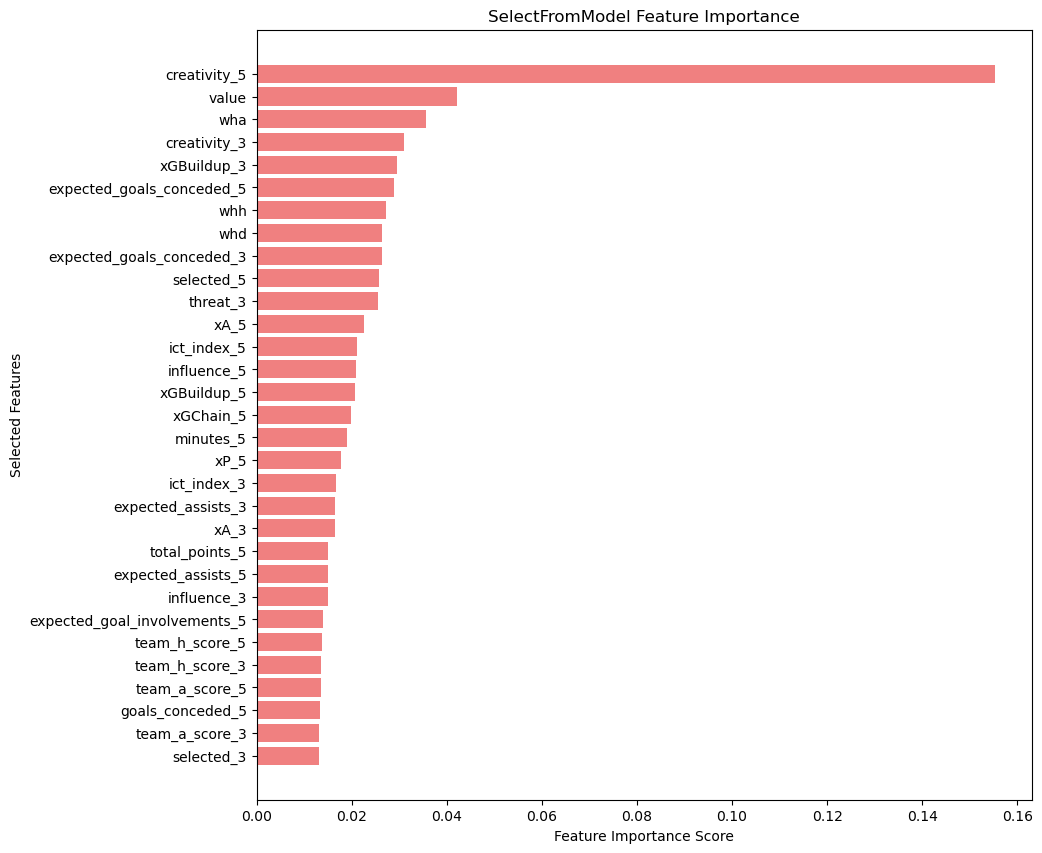

In [138]:
# Feature selection using SelectFromModel
selected_features_mask = dt_selector.get_support()
selected_feature_names = feats__.columns[selected_features_mask]

# Get feature importances
feature_importances = dt_model.feature_importances_[selected_features_mask]

# Sort features by importance
sorted_indices = np.argsort(feature_importances)[::-1]  # Sort descending
sorted_features = np.array(selected_feature_names)[sorted_indices]
sorted_importances = feature_importances[sorted_indices]

# Plot feature importance
plt.figure(figsize=(10, 10))
plt.barh(sorted_features, sorted_importances, color='lightcoral')
plt.xlabel("Feature Importance Score")
plt.ylabel("Selected Features")
plt.title("SelectFromModel Feature Importance")
plt.gca().invert_yaxis()  # Show most important feature on top
plt.show()


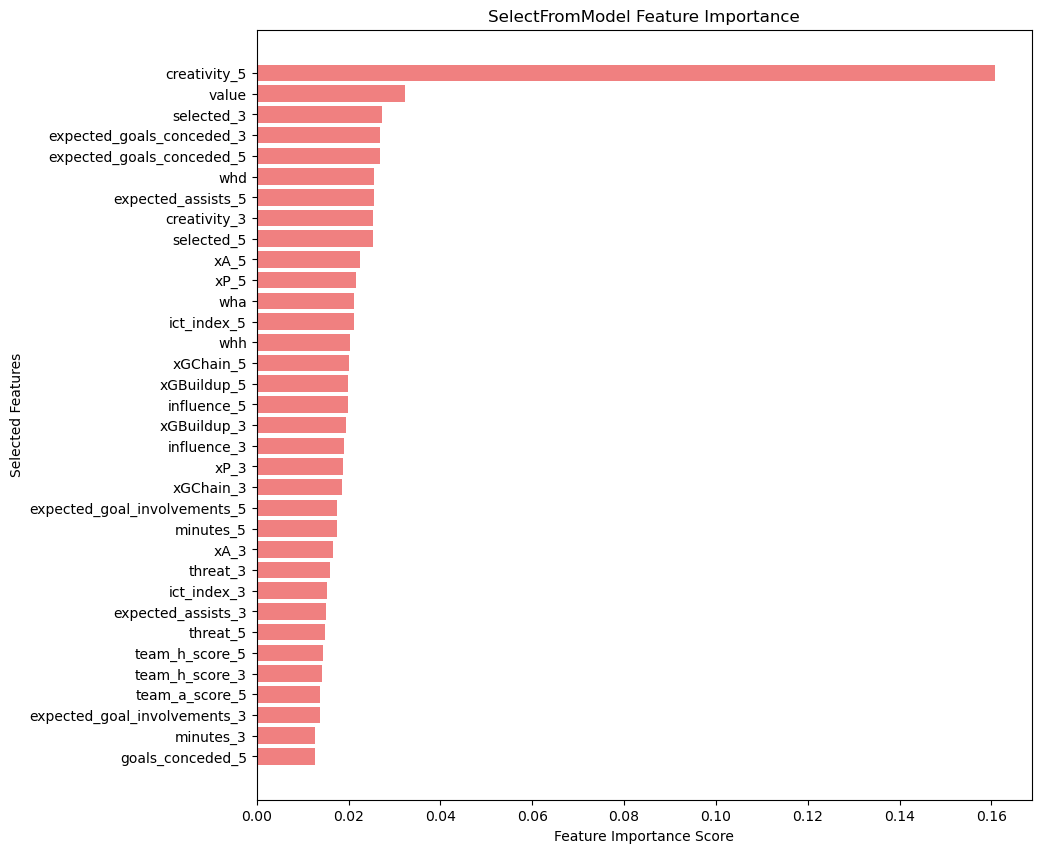

In [139]:
# Feature selection using SelectFromModel
selected_features_mask = rf_selector.get_support()
selected_feature_names = feats__.columns[selected_features_mask]

# Get feature importances
feature_importances = rf_model.feature_importances_[selected_features_mask]

# Sort features by importance
sorted_indices = np.argsort(feature_importances)[::-1]  # Sort descending
sorted_features = np.array(selected_feature_names)[sorted_indices]
sorted_importances = feature_importances[sorted_indices]

# Plot feature importance
plt.figure(figsize=(10, 10))
plt.barh(sorted_features, sorted_importances, color='lightcoral')
plt.xlabel("Feature Importance Score")
plt.ylabel("Selected Features")
plt.title("SelectFromModel Feature Importance")
plt.gca().invert_yaxis()  # Show most important feature on top
plt.show()

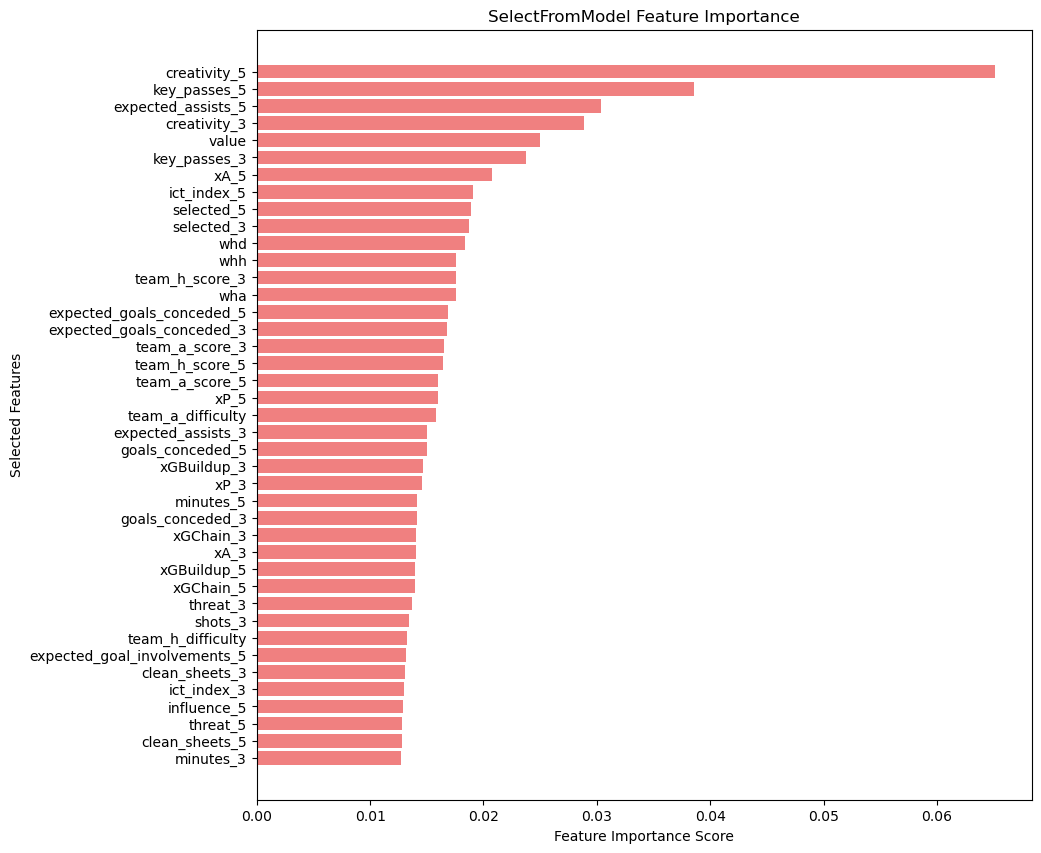

In [140]:
# Feature selection using SelectFromModel
selected_features_mask = extr_selector.get_support()
selected_feature_names = feats__.columns[selected_features_mask]

# Get feature importances
feature_importances = extr_model.feature_importances_[selected_features_mask]

# Sort features by importance
sorted_indices = np.argsort(feature_importances)[::-1]  # Sort descending
sorted_features = np.array(selected_feature_names)[sorted_indices]
sorted_importances = feature_importances[sorted_indices]

# Plot feature importance
plt.figure(figsize=(10, 10))
plt.barh(sorted_features, sorted_importances, color='lightcoral')
plt.xlabel("Feature Importance Score")
plt.ylabel("Selected Features")
plt.title("SelectFromModel Feature Importance")
plt.gca().invert_yaxis()  # Show most important feature on top
plt.show()

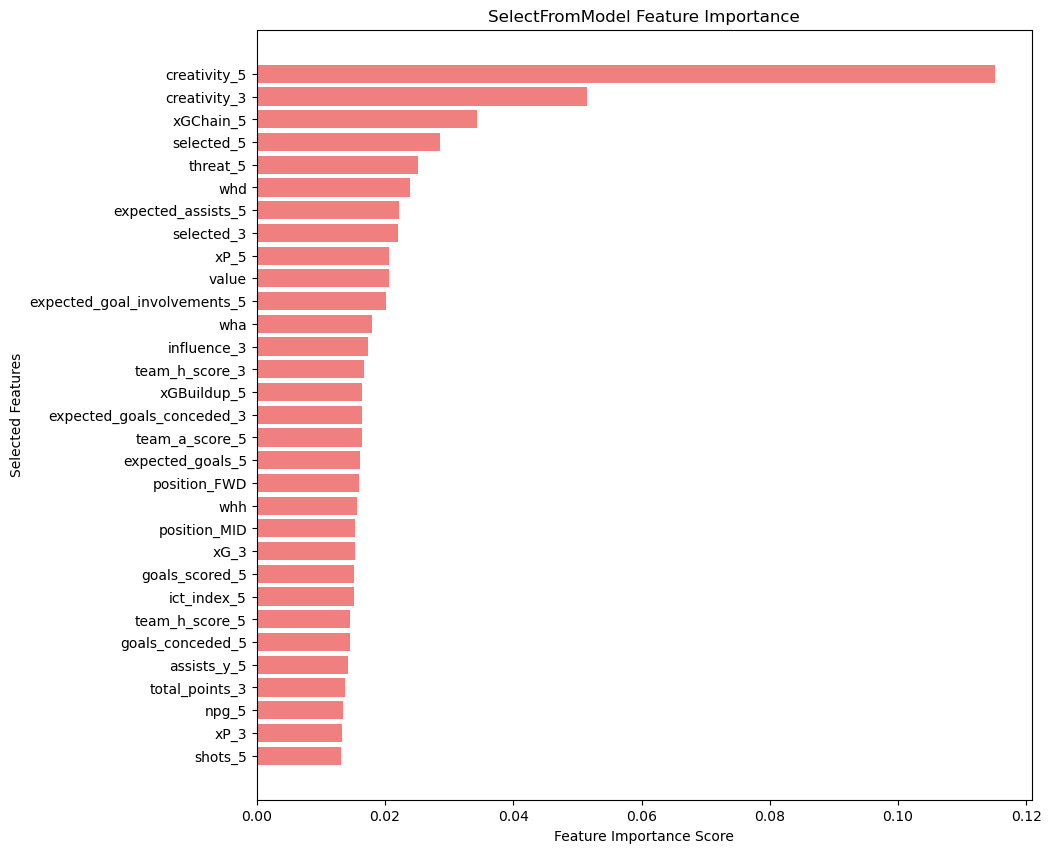

In [141]:
# Feature selection using SelectFromModel
selected_features_mask = xg_selector.get_support()
selected_feature_names = feats__.columns[selected_features_mask]

# Get feature importances
feature_importances = xg_model.feature_importances_[selected_features_mask]

# Sort features by importance
sorted_indices = np.argsort(feature_importances)[::-1]  # Sort descending
sorted_features = np.array(selected_feature_names)[sorted_indices]
sorted_importances = feature_importances[sorted_indices]

# Plot feature importance
plt.figure(figsize=(10, 10))
plt.barh(sorted_features, sorted_importances, color='lightcoral')
plt.xlabel("Feature Importance Score")
plt.ylabel("Selected Features")
plt.title("SelectFromModel Feature Importance")
plt.gca().invert_yaxis()  # Show most important feature on top
plt.show()

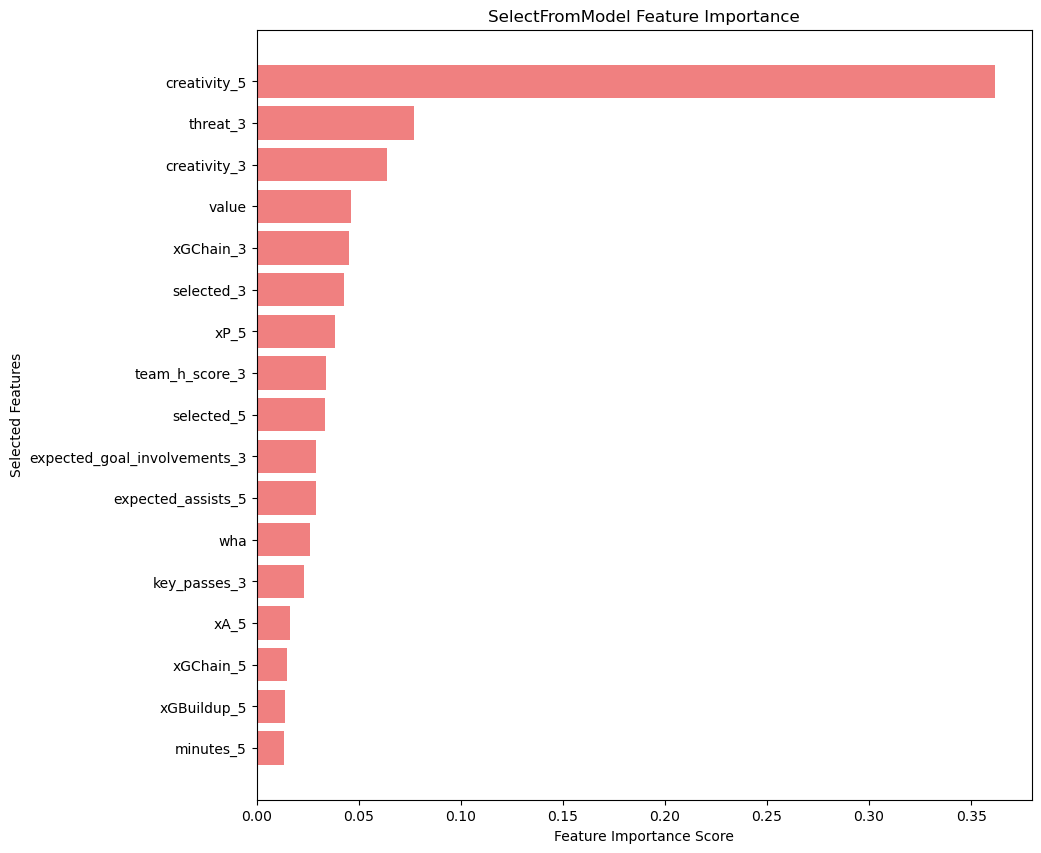

In [142]:
# Feature selection using SelectFromModel
selected_features_mask = ada_selector.get_support()
selected_feature_names = feats__.columns[selected_features_mask]

# Get feature importances
feature_importances = ada_model.feature_importances_[selected_features_mask]

# Sort features by importance
sorted_indices = np.argsort(feature_importances)[::-1]  # Sort descending
sorted_features = np.array(selected_feature_names)[sorted_indices]
sorted_importances = feature_importances[sorted_indices]

# Plot feature importance
plt.figure(figsize=(10, 10))
plt.barh(sorted_features, sorted_importances, color='lightcoral')
plt.xlabel("Feature Importance Score")
plt.ylabel("Selected Features")
plt.title("SelectFromModel Feature Importance")
plt.gca().invert_yaxis()  # Show most important feature on top
plt.show()

#### Linear Model


In [143]:

lin_reg_SFM = Linear_regression(feats_train_SFM_lin, feats_test_SFM_lin, train_SFM_lin, test_SFM_lin)

# lin_reg_SFM
# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(lin_reg_SFM = [lin_reg_SFM['train_MAE'], lin_reg_SFM['test_MAE'], lin_reg_SFM['train_RMSE'], lin_reg_SFM['test_RMSE'], lin_reg_SFM['cv_rmse'], lin_reg_SFM['R2_train'], lin_reg_SFM['R2_test']])
evaluation_stats

Training set RMSE: 0.949956375973095
Test set RMSE: 1.0450605354562872
Training set R2: 0.05757088553051648
Test set R2: 0.06357457436432035


,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM
train_MAE,0.075869,5.720813e-20,0.068064,0.073193,0.073193,0.608152
test_MAE,0.078375,1.043064e-01,0.079319,0.078653,0.078653,0.647553
train_RMSE,0.123292,6.077315e-19,0.105516,0.116899,0.116899,0.949956
test_RMSE,0.128990,1.820021e-01,0.129094,0.128465,0.128465,1.045061
cv_rmse,0.123537,1.805701e-01,0.125535,0.123402,0.123402,0.950029
R2_train,0.153840,1.000000e+00,0.380244,0.239311,0.239311,0.057571
R2_test,0.176158,-6.401555e-01,0.174827,0.182850,0.182850,0.063575


#### DecisionTree Model


In [144]:
dt_reg_SFM = DecisionTreeRegression(feats_train_SFM_dt, feats_test_SFM_dt, train_SFM_dt, test_SFM_dt)

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(dt_reg_SFM = [dt_reg_SFM['train_MAE'], dt_reg_SFM['test_MAE'], dt_reg_SFM['train_RMSE'], dt_reg_SFM['test_RMSE'], dt_reg_SFM['cv_rmse'], dt_reg_SFM['R2_train'], dt_reg_SFM['R2_test']])

evaluation_stats



,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM
train_MAE,0.075869,5.720813e-20,0.068064,0.073193,0.073193,0.608152,1.006006e-17
test_MAE,0.078375,1.043064e-01,0.079319,0.078653,0.078653,0.647553,7.874401e-01
train_RMSE,0.123292,6.077315e-19,0.105516,0.116899,0.116899,0.949956,4.481411e-17
test_RMSE,0.128990,1.820021e-01,0.129094,0.128465,0.128465,1.045061,1.353232e+00
cv_rmse,0.123537,1.805701e-01,0.125535,0.123402,0.123402,0.950029,1.318233e+00
R2_train,0.153840,1.000000e+00,0.380244,0.239311,0.239311,0.057571,1.000000e+00
R2_test,0.176158,-6.401555e-01,0.174827,0.182850,0.182850,0.063575,-5.701275e-01


### RandomForest


In [145]:
hyperparameters = {"criterion": 'friedman_mse', "max_depth": 8, "max_features": 'sqrt', "n_estimators": 20}
rf_reg_SFM = RandomForestRegression(feats_train_SFM_rf, feats_test_SFM_rf, train_SFM_rf.values.ravel(), test_SFM_rf.values.ravel(), hyperparameters)

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(rf_reg_SFM = [rf_reg_SFM['train_MAE'], rf_reg_SFM['test_MAE'], rf_reg_SFM['train_RMSE'], rf_reg_SFM['test_RMSE'], rf_reg_SFM['cv_rmse'], rf_reg_SFM['R2_train'], rf_reg_SFM['R2_test']])

evaluation_stats

,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM,rf_reg_SFM
train_MAE,0.075869,5.720813e-20,0.068064,0.073193,0.073193,0.608152,1.006006e-17,0.495011
test_MAE,0.078375,1.043064e-01,0.079319,0.078653,0.078653,0.647553,7.874401e-01,0.599778
train_RMSE,0.123292,6.077315e-19,0.105516,0.116899,0.116899,0.949956,4.481411e-17,0.764830
test_RMSE,0.128990,1.820021e-01,0.129094,0.128465,0.128465,1.045061,1.353232e+00,0.995264
cv_rmse,0.123537,1.805701e-01,0.125535,0.123402,0.123402,0.950029,1.318233e+00,0.913620
R2_train,0.153840,1.000000e+00,0.380244,0.239311,0.239311,0.057571,1.000000e+00,0.389098
R2_test,0.176158,-6.401555e-01,0.174827,0.182850,0.182850,0.063575,-5.701275e-01,0.150689


### XgBoost


In [146]:
hyperparameters = {'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 150}
xgb_reg_SFM = XGBoostRegression(feats_train_SFM_xg, feats_test_SFM_xg, train_SFM_xg.values.ravel(), test_SFM_xg.values.ravel(), hyperparameters)

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(xgb_reg_SFM = [xgb_reg_SFM['train_MAE'], xgb_reg_SFM['test_MAE'], xgb_reg_SFM['train_RMSE'], xgb_reg_SFM['test_RMSE'], xgb_reg_SFM['cv_rmse'], xgb_reg_SFM['R2_train'], xgb_reg_SFM['R2_test']])
evaluation_stats

,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM,rf_reg_SFM,xgb_reg_SFM
train_MAE,0.075869,5.720813e-20,0.068064,0.073193,0.073193,0.608152,1.006006e-17,0.495011,0.530413
test_MAE,0.078375,1.043064e-01,0.079319,0.078653,0.078653,0.647553,7.874401e-01,0.599778,0.603198
train_RMSE,0.123292,6.077315e-19,0.105516,0.116899,0.116899,0.949956,4.481411e-17,0.764830,0.840290
test_RMSE,0.128990,1.820021e-01,0.129094,0.128465,0.128465,1.045061,1.353232e+00,0.995264,0.996281
cv_rmse,0.123537,1.805701e-01,0.125535,0.123402,0.123402,0.950029,1.318233e+00,0.913620,0.894712
R2_train,0.153840,1.000000e+00,0.380244,0.239311,0.239311,0.057571,1.000000e+00,0.389098,0.262606
R2_test,0.176158,-6.401555e-01,0.174827,0.182850,0.182850,0.063575,-5.701275e-01,0.150689,0.148953


### AdaBoost


In [147]:
hyperparameters = {'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 150}
ada_reg_SFM = XGBoostRegression(feats_train_SFM_ada, feats_test_SFM_ada, train_SFM_ada.values.ravel(), test_SFM_ada.values.ravel(), hyperparameters)

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(ada_reg_SFM = [ada_reg_SFM['train_MAE'], ada_reg_SFM['test_MAE'], ada_reg_SFM['train_RMSE'], ada_reg_SFM['test_RMSE'], ada_reg_SFM['cv_rmse'], ada_reg_SFM['R2_train'], ada_reg_SFM['R2_test']])
evaluation_stats

,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM,rf_reg_SFM,xgb_reg_SFM,ada_reg_SFM
train_MAE,0.075869,5.720813e-20,0.068064,0.073193,0.073193,0.608152,1.006006e-17,0.495011,0.530413,0.533870
test_MAE,0.078375,1.043064e-01,0.079319,0.078653,0.078653,0.647553,7.874401e-01,0.599778,0.603198,0.604090
train_RMSE,0.123292,6.077315e-19,0.105516,0.116899,0.116899,0.949956,4.481411e-17,0.764830,0.840290,0.847263
test_RMSE,0.128990,1.820021e-01,0.129094,0.128465,0.128465,1.045061,1.353232e+00,0.995264,0.996281,0.995224
cv_rmse,0.123537,1.805701e-01,0.125535,0.123402,0.123402,0.950029,1.318233e+00,0.913620,0.894712,0.899739
R2_train,0.153840,1.000000e+00,0.380244,0.239311,0.239311,0.057571,1.000000e+00,0.389098,0.262606,0.250317
R2_test,0.176158,-6.401555e-01,0.174827,0.182850,0.182850,0.063575,-5.701275e-01,0.150689,0.148953,0.150757


## VarianceThreshold


## Model(VT)


In [148]:
from sklearn.compose import TransformedTargetRegressor, ColumnTransformer
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import pandas as pd

# Feature preprocessing pipeline
# Split into numerical and categorical columns
bool_cols = feats_train_.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = feats_train_.select_dtypes(include=['object', 'category']).columns.tolist()

# Preprocessing for numerical features
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Preprocessing for categorical features
categorical_transformer = Pipeline(steps=[
    ('one_hot_encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessors in a column transformer
col_trans = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, bool_cols),
        ('cat', categorical_transformer, categorical_cols),
    ]
)

# Scale and remove low-variance features
preprocessor = Pipeline(steps=[
    # ('col_trans', col_trans),
    ('var_threshold', VarianceThreshold(threshold=0.1))
])




In [149]:
def scores(model, feats_train, feats_test, train, test):
    # fit the transofrmer on the train data
    model.fit(feats_train, train)

    # support = model.regressor_.named_steps['preprocessor'].named_steps['var_threshold'].get_support()
    # # print(f"Selected features: {feats_train.columns[support]}")
    # print(len(support), len(feats_train.columns))

    # With the model fitted, we can predict the total_points given the feature_train and feature_test set
    pred_train = model.predict(feats_train)
    pred_test = model.predict(feats_test)

    # Evaluate the performance of the model on both sets using the mean absolute error
    train_MAE = mean_absolute_error(train, pred_train)
    test_MAE = mean_absolute_error(test, pred_test)

    # Evaluate the performance of the model on both sets using the mean square error
    train_MSE = mean_squared_error(train, pred_train)
    test_MSE = mean_squared_error(test, pred_test)

    # Evaluate the performance of the model on both sets using the root mean square error
    train_RMSE = root_mean_squared_error(train, pred_train)
    test_RMSE = root_mean_squared_error(test, pred_test)

    # Get the score of the model or the coeeficient of determination i.e how much of the target value can be explained by the model.
    # In this case, 0.6 implies that 60% of the variations in the target value can be explained by the model and 40% is not explainable
    R2_train = model.score(feats_train, train)
    R2_test = model.score(feats_test, test)

    # If the test error significantly differs from the train error, then there is either overfitting or underfitting
    # RMSE, just like the squared loss function that it derives from, effectively penalizes larger errors more severely.
    print('Training set RMSE: {}'.format(train_RMSE))
    print('Test set RMSE: {}'.format(test_RMSE))

    print('Training set R2: {}'.format(R2_train))
    print('Test set R2: {}'.format(R2_test))

    # Carry out cross validation of the model.
    # The evaluation method is the root mean square error
    # The method expects a utility function (greater is better) and so the scoring function is the opposite of the the RMSE. Hence the -ve
    tree_rmses = -cross_val_score(model, feats_train, train,
                                    scoring="neg_root_mean_squared_error", cv=10)

    return {'train_MAE': train_MAE, 'test_MAE': test_MAE, 'train_MSE': train_MSE, 'test_MSE': test_MSE, 'train_RMSE': train_RMSE, 'test_RMSE': test_RMSE, 'cv_rmse': tree_rmses.mean(), 'R2_train': R2_train, 'R2_test': R2_test}


In [150]:
feats_test_.shape, test.shape

((2207, 79), (2207, 1))

##### Linear Model


In [151]:

# Full pipeline including the regression model
pipeline = Pipeline(steps=[
    # ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# TransformedTargetRegressor for target scaling
model = TransformedTargetRegressor(
    regressor=pipeline,
    transformer=StandardScaler()
)

# Model predictions
VarT_lin_reg = scores(model, feats_train_, feats_test_, train.values.ravel(), test.values.ravel())

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(VarT_lin_reg =  [VarT_lin_reg['train_MAE'], VarT_lin_reg['test_MAE'],  VarT_lin_reg['train_RMSE'], VarT_lin_reg['test_RMSE'], VarT_lin_reg['cv_rmse'], VarT_lin_reg['R2_train'], VarT_lin_reg['R2_test']])

evaluation_stats

Training set RMSE: 0.8840554896515186
Test set RMSE: 0.9832504345674797
Training set R2: 0.18379280114994645
Test set R2: 0.17106859157372978


,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM,rf_reg_SFM,xgb_reg_SFM,ada_reg_SFM,VarT_lin_reg
train_MAE,0.075869,5.720813e-20,0.068064,0.073193,0.073193,0.608152,1.006006e-17,0.495011,0.530413,0.533870,0.545482
test_MAE,0.078375,1.043064e-01,0.079319,0.078653,0.078653,0.647553,7.874401e-01,0.599778,0.603198,0.604090,0.588346
train_RMSE,0.123292,6.077315e-19,0.105516,0.116899,0.116899,0.949956,4.481411e-17,0.764830,0.840290,0.847263,0.884055
test_RMSE,0.128990,1.820021e-01,0.129094,0.128465,0.128465,1.045061,1.353232e+00,0.995264,0.996281,0.995224,0.983250
cv_rmse,0.123537,1.805701e-01,0.125535,0.123402,0.123402,0.950029,1.318233e+00,0.913620,0.894712,0.899739,0.892851
R2_train,0.153840,1.000000e+00,0.380244,0.239311,0.239311,0.057571,1.000000e+00,0.389098,0.262606,0.250317,0.183793
R2_test,0.176158,-6.401555e-01,0.174827,0.182850,0.182850,0.063575,-5.701275e-01,0.150689,0.148953,0.150757,0.171069


##### DecisionTree Model


In [152]:
# Full pipeline including the regression model
pipeline = Pipeline(steps=[
    # ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor())
])

# TransformedTargetRegressor for target scaling
dt_model = TransformedTargetRegressor(
    regressor=pipeline,
    transformer=StandardScaler()
)

VarT_dt_reg = scores(dt_model, feats_train_, feats_test_, train.values.ravel(), test.values.ravel())

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(VarT_dt_reg = [VarT_dt_reg['train_MAE'], VarT_dt_reg['test_MAE'], VarT_dt_reg['train_RMSE'], VarT_dt_reg['test_RMSE'], VarT_dt_reg['cv_rmse'], VarT_dt_reg['R2_train'], VarT_dt_reg['R2_test']])

evaluation_stats



Training set RMSE: 2.3101011383538548e-17
Test set RMSE: 1.3769877894337856
Training set R2: 1.0
Test set R2: -0.6257377103723407


,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM,rf_reg_SFM,xgb_reg_SFM,ada_reg_SFM,VarT_lin_reg,VarT_dt_reg
train_MAE,0.075869,5.720813e-20,0.068064,0.073193,0.073193,0.608152,1.006006e-17,0.495011,0.530413,0.533870,0.545482,3.213936e-18
test_MAE,0.078375,1.043064e-01,0.079319,0.078653,0.078653,0.647553,7.874401e-01,0.599778,0.603198,0.604090,0.588346,7.881412e-01
train_RMSE,0.123292,6.077315e-19,0.105516,0.116899,0.116899,0.949956,4.481411e-17,0.764830,0.840290,0.847263,0.884055,2.310101e-17
test_RMSE,0.128990,1.820021e-01,0.129094,0.128465,0.128465,1.045061,1.353232e+00,0.995264,0.996281,0.995224,0.983250,1.376988e+00
cv_rmse,0.123537,1.805701e-01,0.125535,0.123402,0.123402,0.950029,1.318233e+00,0.913620,0.894712,0.899739,0.892851,1.342605e+00
R2_train,0.153840,1.000000e+00,0.380244,0.239311,0.239311,0.057571,1.000000e+00,0.389098,0.262606,0.250317,0.183793,1.000000e+00
R2_test,0.176158,-6.401555e-01,0.174827,0.182850,0.182850,0.063575,-5.701275e-01,0.150689,0.148953,0.150757,0.171069,-6.257377e-01


##### RandomForest Model


In [153]:
hyperparameters = {"criterion": 'friedman_mse', "max_depth": 8, "max_features": 'sqrt', "n_estimators": 20}

# Full pipeline including the regression model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
                        n_estimators=hyperparameters['n_estimators'],
                        max_depth=hyperparameters['max_depth'],
                        criterion=hyperparameters['criterion'], random_state=18
                        ))
])

# TransformedTargetRegressor for target scaling
rf_model = TransformedTargetRegressor(
    regressor=pipeline,
    transformer=StandardScaler()
)
# Store the model evaluation details in a DataFrame
VarT_rf_reg = scores(rf_model, feats_train_, feats_test_, train.values.ravel(), test.values.ravel())

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(VarT_rf_reg = [VarT_rf_reg['train_MAE'], VarT_rf_reg['test_MAE'], VarT_rf_reg['train_RMSE'], VarT_rf_reg['test_RMSE'], VarT_rf_reg['cv_rmse'], VarT_rf_reg['R2_train'], VarT_rf_reg['R2_test']])
evaluation_stats

Training set RMSE: 0.7603081615626783
Test set RMSE: 0.9906186185333428
Training set R2: 0.3963006959262857
Test set R2: 0.15859851557932225


,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM,rf_reg_SFM,xgb_reg_SFM,ada_reg_SFM,VarT_lin_reg,VarT_dt_reg,VarT_rf_reg
train_MAE,0.075869,5.720813e-20,0.068064,0.073193,0.073193,0.608152,1.006006e-17,0.495011,0.530413,0.533870,0.545482,3.213936e-18,0.493040
test_MAE,0.078375,1.043064e-01,0.079319,0.078653,0.078653,0.647553,7.874401e-01,0.599778,0.603198,0.604090,0.588346,7.881412e-01,0.597813
train_RMSE,0.123292,6.077315e-19,0.105516,0.116899,0.116899,0.949956,4.481411e-17,0.764830,0.840290,0.847263,0.884055,2.310101e-17,0.760308
test_RMSE,0.128990,1.820021e-01,0.129094,0.128465,0.128465,1.045061,1.353232e+00,0.995264,0.996281,0.995224,0.983250,1.376988e+00,0.990619
cv_rmse,0.123537,1.805701e-01,0.125535,0.123402,0.123402,0.950029,1.318233e+00,0.913620,0.894712,0.899739,0.892851,1.342605e+00,0.911061
R2_train,0.153840,1.000000e+00,0.380244,0.239311,0.239311,0.057571,1.000000e+00,0.389098,0.262606,0.250317,0.183793,1.000000e+00,0.396301
R2_test,0.176158,-6.401555e-01,0.174827,0.182850,0.182850,0.063575,-5.701275e-01,0.150689,0.148953,0.150757,0.171069,-6.257377e-01,0.158599


##### XgBoost Model


In [154]:
hyperparameters = {'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 150}

# Full pipeline including the regression model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb(learning_rate=hyperparameters["learning_rate"],
                    n_estimators=hyperparameters["n_estimators"],
                    max_depth=hyperparameters["max_depth"],
                    eval_metric='rmsle'))
])

# TransformedTargetRegressor for target scaling
rf_model = TransformedTargetRegressor(
    regressor=pipeline,
    transformer=StandardScaler()
)

VarT_xgb_reg = scores(rf_model, feats_train_, feats_test_, train.values.ravel(), test.values.ravel())



# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(VarT_xgb_reg = [VarT_xgb_reg['train_MAE'], VarT_xgb_reg['test_MAE'], VarT_xgb_reg['train_RMSE'], VarT_xgb_reg['test_RMSE'], VarT_xgb_reg['cv_rmse'], VarT_xgb_reg['R2_train'], VarT_xgb_reg['R2_test']])
evaluation_stats

Training set RMSE: 0.832931766943205
Test set RMSE: 0.9878855639982805
Training set R2: 0.2754635782125935
Test set R2: 0.16323485872732113


,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM,rf_reg_SFM,xgb_reg_SFM,ada_reg_SFM,VarT_lin_reg,VarT_dt_reg,VarT_rf_reg,VarT_xgb_reg
train_MAE,0.075869,5.720813e-20,0.068064,0.073193,0.073193,0.608152,1.006006e-17,0.495011,0.530413,0.533870,0.545482,3.213936e-18,0.493040,0.523922
test_MAE,0.078375,1.043064e-01,0.079319,0.078653,0.078653,0.647553,7.874401e-01,0.599778,0.603198,0.604090,0.588346,7.881412e-01,0.597813,0.596621
train_RMSE,0.123292,6.077315e-19,0.105516,0.116899,0.116899,0.949956,4.481411e-17,0.764830,0.840290,0.847263,0.884055,2.310101e-17,0.760308,0.832932
test_RMSE,0.128990,1.820021e-01,0.129094,0.128465,0.128465,1.045061,1.353232e+00,0.995264,0.996281,0.995224,0.983250,1.376988e+00,0.990619,0.987886
cv_rmse,0.123537,1.805701e-01,0.125535,0.123402,0.123402,0.950029,1.318233e+00,0.913620,0.894712,0.899739,0.892851,1.342605e+00,0.911061,0.891968
R2_train,0.153840,1.000000e+00,0.380244,0.239311,0.239311,0.057571,1.000000e+00,0.389098,0.262606,0.250317,0.183793,1.000000e+00,0.396301,0.275464
R2_test,0.176158,-6.401555e-01,0.174827,0.182850,0.182850,0.063575,-5.701275e-01,0.150689,0.148953,0.150757,0.171069,-6.257377e-01,0.158599,0.163235


## KBest


In [156]:
from sklearn.feature_selection import SelectKBest, mutual_info_regression

k_rf_model = RandomForestRegressor(n_estimators=20,  max_depth=8, criterion='friedman_mse', max_features='sqrt', random_state=18)

score_list  = []
i = len(feats_train_.columns.tolist())
for k in range(1, i):
  selector = SelectKBest(mutual_info_regression, k=k)
  k_sel_X_train =  selector.fit_transform(feats_train_, train.values.ravel())

  k_rf_model.fit(k_sel_X_train, train.values.ravel())

  k_sel_cols = feats_train_.columns[selector.get_support()]
  k_sel_X_test = feats_test_[k_sel_cols]
  score = round(k_rf_model.score(k_sel_X_test.values, test ), 3)

  score_list.append(score)
print(score_list, score_list.index(max(score_list)))
num_of_feat = score_list.index(max(score_list)) # find the highest score. We will use  that as the value of k

selector = SelectKBest(mutual_info_regression, k=num_of_feat+1)
selector.fit_transform(feats_train_, train.values.ravel())

sel_feats = selector.get_feature_names_out()

feats_train_KBest, feats_test_KBest, train_KBest, test_KBest = train_test_split(feats__[sel_feats], xa_ , test_size=0.2, random_state=42)

[0.119, 0.126, 0.129, 0.129, 0.118, 0.114, 0.128, 0.14, 0.134, 0.141, 0.151, 0.132, 0.135, 0.141, 0.15, 0.14, 0.139, 0.153, 0.138, 0.144, 0.15, 0.148, 0.146, 0.144, 0.14, 0.143, 0.159, 0.14, 0.141, 0.143, 0.159, 0.144, 0.151, 0.148, 0.131, 0.157, 0.149, 0.14, 0.145, 0.143, 0.15, 0.142, 0.15, 0.139, 0.162, 0.142, 0.146, 0.158, 0.147, 0.143, 0.147, 0.136, 0.147, 0.141, 0.139, 0.148, 0.152, 0.137, 0.144, 0.152, 0.146, 0.142, 0.14, 0.135, 0.156, 0.142, 0.142, 0.145, 0.148, 0.145, 0.144, 0.145, 0.157, 0.139, 0.157, 0.147, 0.136, 0.153] 44


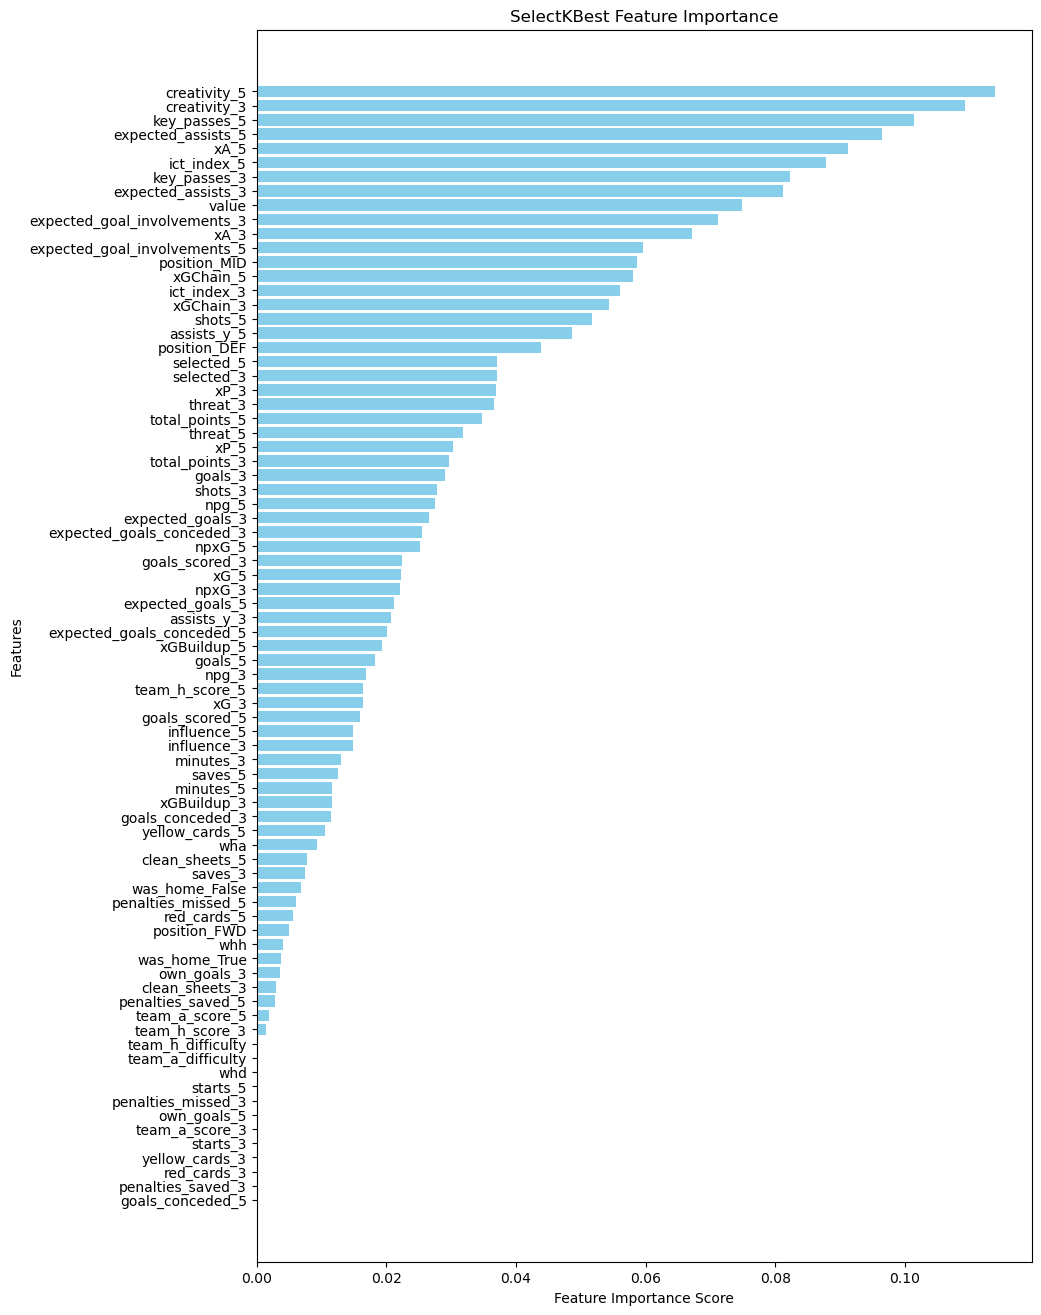

In [157]:
# Get feature scores and names
feature_scores = selector.scores_  # Feature importance scores
feature_names = feats__.columns  # Feature names

# Sort features by importance
sorted_indices = np.argsort(feature_scores)[::-1]  # Sort descending
sorted_features = np.array(feature_names)[sorted_indices]
sorted_scores = feature_scores[sorted_indices]

# Plot feature importance
plt.figure(figsize=(10, 16))
plt.barh(sorted_features, sorted_scores, color='skyblue')
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("SelectKBest Feature Importance")
plt.gca().invert_yaxis()  # Show most important feature on top
plt.show()

### Linear Model


In [159]:

lin_reg_KBest = Linear_regression(feats_train_KBest, feats_test_KBest, train_KBest.values.ravel(), test_KBest.values.ravel())


# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(lin_reg_KBest = [lin_reg_KBest['train_MAE'], lin_reg_KBest['test_MAE'], lin_reg_KBest['train_RMSE'], lin_reg_KBest['test_RMSE'], lin_reg_KBest['cv_rmse'], lin_reg_KBest['R2_train'], lin_reg_KBest['R2_test']])

evaluation_stats

Training set RMSE: 0.8927143686966698
Test set RMSE: 0.9899094316781605
Training set R2: 0.16772582231971145
Test set R2: 0.1598028080647772


,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM,rf_reg_SFM,xgb_reg_SFM,ada_reg_SFM,VarT_lin_reg,VarT_dt_reg,VarT_rf_reg,VarT_xgb_reg,lin_reg_KBest
train_MAE,0.075869,5.720813e-20,0.068064,0.073193,0.073193,0.608152,1.006006e-17,0.495011,0.530413,0.533870,0.545482,3.213936e-18,0.493040,0.523922,0.551418
test_MAE,0.078375,1.043064e-01,0.079319,0.078653,0.078653,0.647553,7.874401e-01,0.599778,0.603198,0.604090,0.588346,7.881412e-01,0.597813,0.596621,0.594470
train_RMSE,0.123292,6.077315e-19,0.105516,0.116899,0.116899,0.949956,4.481411e-17,0.764830,0.840290,0.847263,0.884055,2.310101e-17,0.760308,0.832932,0.892714
test_RMSE,0.128990,1.820021e-01,0.129094,0.128465,0.128465,1.045061,1.353232e+00,0.995264,0.996281,0.995224,0.983250,1.376988e+00,0.990619,0.987886,0.989909
cv_rmse,0.123537,1.805701e-01,0.125535,0.123402,0.123402,0.950029,1.318233e+00,0.913620,0.894712,0.899739,0.892851,1.342605e+00,0.911061,0.891968,0.898395
R2_train,0.153840,1.000000e+00,0.380244,0.239311,0.239311,0.057571,1.000000e+00,0.389098,0.262606,0.250317,0.183793,1.000000e+00,0.396301,0.275464,0.167726
R2_test,0.176158,-6.401555e-01,0.174827,0.182850,0.182850,0.063575,-5.701275e-01,0.150689,0.148953,0.150757,0.171069,-6.257377e-01,0.158599,0.163235,0.159803


### Decision Tree


In [160]:
dt_reg_KBest = DecisionTreeRegression(feats_train_KBest, feats_test_KBest, train_KBest.values.ravel(), test_KBest.values.ravel())

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(dt_reg_KBest = [dt_reg_KBest['train_MAE'], dt_reg_KBest['test_MAE'], dt_reg_KBest['train_RMSE'], dt_reg_KBest['test_RMSE'], dt_reg_KBest['cv_rmse'], dt_reg_KBest['R2_train'], dt_reg_KBest['R2_test']])

evaluation_stats



,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM,rf_reg_SFM,xgb_reg_SFM,ada_reg_SFM,VarT_lin_reg,VarT_dt_reg,VarT_rf_reg,VarT_xgb_reg,lin_reg_KBest,dt_reg_KBest
train_MAE,0.075869,5.720813e-20,0.068064,0.073193,0.073193,0.608152,1.006006e-17,0.495011,0.530413,0.533870,0.545482,3.213936e-18,0.493040,0.523922,0.551418,0.017319
test_MAE,0.078375,1.043064e-01,0.079319,0.078653,0.078653,0.647553,7.874401e-01,0.599778,0.603198,0.604090,0.588346,7.881412e-01,0.597813,0.596621,0.594470,0.783945
train_RMSE,0.123292,6.077315e-19,0.105516,0.116899,0.116899,0.949956,4.481411e-17,0.764830,0.840290,0.847263,0.884055,2.310101e-17,0.760308,0.832932,0.892714,0.128115
test_RMSE,0.128990,1.820021e-01,0.129094,0.128465,0.128465,1.045061,1.353232e+00,0.995264,0.996281,0.995224,0.983250,1.376988e+00,0.990619,0.987886,0.989909,1.342724
cv_rmse,0.123537,1.805701e-01,0.125535,0.123402,0.123402,0.950029,1.318233e+00,0.913620,0.894712,0.899739,0.892851,1.342605e+00,0.911061,0.891968,0.898395,1.343759
R2_train,0.153840,1.000000e+00,0.380244,0.239311,0.239311,0.057571,1.000000e+00,0.389098,0.262606,0.250317,0.183793,1.000000e+00,0.396301,0.275464,0.167726,0.982859
R2_test,0.176158,-6.401555e-01,0.174827,0.182850,0.182850,0.063575,-5.701275e-01,0.150689,0.148953,0.150757,0.171069,-6.257377e-01,0.158599,0.163235,0.159803,-0.545837


### RandomForest


In [162]:
hyperparameters = {"criterion": 'friedman_mse', "max_depth": 8, "max_features": 'sqrt', "n_estimators": 20}
rf_reg_KBest = RandomForestRegression(feats_train_KBest, feats_test_KBest, train_KBest.values.ravel(), test_KBest.values.ravel(), hyperparameters)

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(rf_reg_KBest = [rf_reg_KBest['train_MAE'], rf_reg_KBest['test_MAE'], rf_reg_KBest['train_RMSE'], rf_reg_KBest['test_RMSE'], rf_reg_KBest['cv_rmse'], rf_reg_KBest['R2_train'], rf_reg_KBest['R2_test']])

evaluation_stats

,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM,rf_reg_SFM,xgb_reg_SFM,ada_reg_SFM,VarT_lin_reg,VarT_dt_reg,VarT_rf_reg,VarT_xgb_reg,lin_reg_KBest,dt_reg_KBest,rf_reg_KBest
train_MAE,0.075869,5.720813e-20,0.068064,0.073193,0.073193,0.608152,1.006006e-17,0.495011,0.530413,0.533870,0.545482,3.213936e-18,0.493040,0.523922,0.551418,0.017319,0.494732
test_MAE,0.078375,1.043064e-01,0.079319,0.078653,0.078653,0.647553,7.874401e-01,0.599778,0.603198,0.604090,0.588346,7.881412e-01,0.597813,0.596621,0.594470,0.783945,0.596907
train_RMSE,0.123292,6.077315e-19,0.105516,0.116899,0.116899,0.949956,4.481411e-17,0.764830,0.840290,0.847263,0.884055,2.310101e-17,0.760308,0.832932,0.892714,0.128115,0.766234
test_RMSE,0.128990,1.820021e-01,0.129094,0.128465,0.128465,1.045061,1.353232e+00,0.995264,0.996281,0.995224,0.983250,1.376988e+00,0.990619,0.987886,0.989909,1.342724,0.993104
cv_rmse,0.123537,1.805701e-01,0.125535,0.123402,0.123402,0.950029,1.318233e+00,0.913620,0.894712,0.899739,0.892851,1.342605e+00,0.911061,0.891968,0.898395,1.343759,0.910232
R2_train,0.153840,1.000000e+00,0.380244,0.239311,0.239311,0.057571,1.000000e+00,0.389098,0.262606,0.250317,0.183793,1.000000e+00,0.396301,0.275464,0.167726,0.982859,0.386854
R2_test,0.176158,-6.401555e-01,0.174827,0.182850,0.182850,0.063575,-5.701275e-01,0.150689,0.148953,0.150757,0.171069,-6.257377e-01,0.158599,0.163235,0.159803,-0.545837,0.154372


### XgBoost


In [163]:
hyperparameters = {'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 150}
xgb_reg_KBest = XGBoostRegression(feats_train_KBest, feats_test_KBest, train_KBest.values.ravel(), test_KBest.values.ravel(), hyperparameters)

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(xgb_reg_KBest = [xgb_reg_KBest['train_MAE'], xgb_reg_KBest['test_MAE'], xgb_reg_KBest['train_RMSE'], xgb_reg_KBest['test_RMSE'], xgb_reg_KBest['cv_rmse'], xgb_reg_KBest['R2_train'], xgb_reg_KBest['R2_test']])
evaluation_stats

,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM,rf_reg_SFM,xgb_reg_SFM,ada_reg_SFM,VarT_lin_reg,VarT_dt_reg,VarT_rf_reg,VarT_xgb_reg,lin_reg_KBest,dt_reg_KBest,rf_reg_KBest,xgb_reg_KBest
train_MAE,0.075869,5.720813e-20,0.068064,0.073193,0.073193,0.608152,1.006006e-17,0.495011,0.530413,0.533870,0.545482,3.213936e-18,0.493040,0.523922,0.551418,0.017319,0.494732,0.530333
test_MAE,0.078375,1.043064e-01,0.079319,0.078653,0.078653,0.647553,7.874401e-01,0.599778,0.603198,0.604090,0.588346,7.881412e-01,0.597813,0.596621,0.594470,0.783945,0.596907,0.601117
train_RMSE,0.123292,6.077315e-19,0.105516,0.116899,0.116899,0.949956,4.481411e-17,0.764830,0.840290,0.847263,0.884055,2.310101e-17,0.760308,0.832932,0.892714,0.128115,0.766234,0.840409
test_RMSE,0.128990,1.820021e-01,0.129094,0.128465,0.128465,1.045061,1.353232e+00,0.995264,0.996281,0.995224,0.983250,1.376988e+00,0.990619,0.987886,0.989909,1.342724,0.993104,0.993692
cv_rmse,0.123537,1.805701e-01,0.125535,0.123402,0.123402,0.950029,1.318233e+00,0.913620,0.894712,0.899739,0.892851,1.342605e+00,0.911061,0.891968,0.898395,1.343759,0.910232,0.896605
R2_train,0.153840,1.000000e+00,0.380244,0.239311,0.239311,0.057571,1.000000e+00,0.389098,0.262606,0.250317,0.183793,1.000000e+00,0.396301,0.275464,0.167726,0.982859,0.386854,0.262398
R2_test,0.176158,-6.401555e-01,0.174827,0.182850,0.182850,0.063575,-5.701275e-01,0.150689,0.148953,0.150757,0.171069,-6.257377e-01,0.158599,0.163235,0.159803,-0.545837,0.154372,0.153370


### AdaBoost


In [164]:
hyperparameters = {'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 150}
ada_reg_KBest = XGBoostRegression(feats_train_KBest, feats_test_KBest, train_KBest.values.ravel(), test_KBest.values.ravel(), hyperparameters)

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(ada_reg_KBest = [ada_reg_KBest['train_MAE'], ada_reg_KBest['test_MAE'], ada_reg_KBest['train_RMSE'], ada_reg_KBest['test_RMSE'], ada_reg_KBest['cv_rmse'], ada_reg_KBest['R2_train'], ada_reg_KBest['R2_test']])
evaluation_stats

,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM,rf_reg_SFM,xgb_reg_SFM,ada_reg_SFM,VarT_lin_reg,VarT_dt_reg,VarT_rf_reg,VarT_xgb_reg,lin_reg_KBest,dt_reg_KBest,rf_reg_KBest,xgb_reg_KBest,ada_reg_KBest
train_MAE,0.075869,5.720813e-20,0.068064,0.073193,0.073193,0.608152,1.006006e-17,0.495011,0.530413,0.533870,0.545482,3.213936e-18,0.493040,0.523922,0.551418,0.017319,0.494732,0.530333,0.530333
test_MAE,0.078375,1.043064e-01,0.079319,0.078653,0.078653,0.647553,7.874401e-01,0.599778,0.603198,0.604090,0.588346,7.881412e-01,0.597813,0.596621,0.594470,0.783945,0.596907,0.601117,0.601117
train_RMSE,0.123292,6.077315e-19,0.105516,0.116899,0.116899,0.949956,4.481411e-17,0.764830,0.840290,0.847263,0.884055,2.310101e-17,0.760308,0.832932,0.892714,0.128115,0.766234,0.840409,0.840409
test_RMSE,0.128990,1.820021e-01,0.129094,0.128465,0.128465,1.045061,1.353232e+00,0.995264,0.996281,0.995224,0.983250,1.376988e+00,0.990619,0.987886,0.989909,1.342724,0.993104,0.993692,0.993692
cv_rmse,0.123537,1.805701e-01,0.125535,0.123402,0.123402,0.950029,1.318233e+00,0.913620,0.894712,0.899739,0.892851,1.342605e+00,0.911061,0.891968,0.898395,1.343759,0.910232,0.896605,0.896605
R2_train,0.153840,1.000000e+00,0.380244,0.239311,0.239311,0.057571,1.000000e+00,0.389098,0.262606,0.250317,0.183793,1.000000e+00,0.396301,0.275464,0.167726,0.982859,0.386854,0.262398,0.262398
R2_test,0.176158,-6.401555e-01,0.174827,0.182850,0.182850,0.063575,-5.701275e-01,0.150689,0.148953,0.150757,0.171069,-6.257377e-01,0.158599,0.163235,0.159803,-0.545837,0.154372,0.153370,0.153370


# Hyperparameter Tunning

Picked XGBoost


In [165]:

from sklearn.model_selection import RandomizedSearchCV

# Define XGBoost model
xgb_model = xgb(objective='reg:squarederror', random_state=42)

# Define hyperparameter grid
param_dist = {
    'n_estimators': [100, 200, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'max_depth': [3, 5, 7, 10],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.3, 0.5, 1.0],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 1, 10],
    'reg_lambda': [0, 0.01, 0.1, 1, 10]
}

# Perform Randomized Search
random_search = RandomizedSearchCV(
    xgb_model, param_distributions=param_dist,
    n_iter=50, scoring='neg_mean_absolute_error',
    cv=5, verbose=2, random_state=42, n_jobs=-1
)

# Fit to training data
random_search.fit(feats_train, xa_train.values.ravel())

# Best parameters
print("Best Parameters:", random_search.best_params_)

# Best model
best_xgb = random_search.best_estimator_


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'subsample': 0.6, 'reg_lambda': 0.1, 'reg_alpha': 1, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.6}


In [167]:
random_search.best_params_

{'subsample': 0.6,
 'reg_lambda': 0.1,
 'reg_alpha': 1,
 'n_estimators': 100,
 'min_child_weight': 3,
 'max_depth': 7,
 'learning_rate': 0.05,
 'gamma': 0.1,
 'colsample_bytree': 0.6}

In [166]:
from sklearn.model_selection import GridSearchCV

# Define refined grid based on RandomizedSearchCV results
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.02, 0.03, 0.05, 0.06, 0.07],
    'max_depth': [6, 7, 8],
    'min_child_weight': [2, 3, 4],
    'gamma': [0.025,0.05, 0.075, 0.1, 0.125,0.15, 0.2],
    'subsample': [0.4, 0.6, 0.5],
    'colsample_bytree': [0.4, 0.6, 0.5],
    'reg_alpha': [0.5, 1, 1.5],
    'reg_lambda': [0.05, 0.1,0.15]
}

grid_search = GridSearchCV(
    xgb_model, param_grid, scoring='neg_mean_absolute_error',
    cv=5, verbose=2, n_jobs=-1
)

grid_search.fit(feats_train, xa_train.values.ravel())

print("Best Grid Parameters:", grid_search.best_params_)

# Best model
best_xgb = grid_search.best_estimator_


Fitting 5 folds for each of 76545 candidates, totalling 382725 fits


KeyboardInterrupt: 